# Cartesian Pendulum Example (3D, Moving Pivot)

This notebook mirrors the spring example structure but simulates a 3D Cartesian pendulum with a moving pivot parameterized by environment variable $X$.

In [1]:
from pathlib import Path
import sys
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[0]
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

np.set_printoptions(precision=4, suppress=True)


In [2]:
@dataclass(frozen=True)
class CartesianPendulumParams:
    mass: float = 1.0
    length: float = 1.0
    gravity: float = 9.81

    def validate(self):
        if self.mass <= 0:
            raise ValueError("mass must be positive")
        if self.length <= 0:
            raise ValueError("length must be positive")
        if self.gravity <= 0:
            raise ValueError("gravity must be positive")


def sample_env_X(
    n_samples: int,
    K: int = 2,
    A_max: float = 0.25,
    omega_range: tuple[float, float] = (0.8, 2.0),
    seed: int | None = 0,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    w_min, w_max = omega_range

    X = np.empty((n_samples, 7 * K), dtype=float)
    for k in range(K):
        cols = slice(7 * k, 7 * (k + 1))
        Ax = rng.uniform(0.0, A_max, size=n_samples)
        Ay = rng.uniform(0.0, A_max, size=n_samples)
        Az = rng.uniform(0.0, A_max, size=n_samples)
        w = rng.uniform(w_min, w_max, size=n_samples)
        phix = rng.uniform(0.0, 2.0 * np.pi, size=n_samples)
        phiy = rng.uniform(0.0, 2.0 * np.pi, size=n_samples)
        phiz = rng.uniform(0.0, 2.0 * np.pi, size=n_samples)
        X[:, cols] = np.stack([Ax, Ay, Az, w, phix, phiy, phiz], axis=1)
    return X


def pivot_kinematics(t: float, X: np.ndarray, K: int, a0: np.ndarray):
    N = X.shape[0]
    a = np.broadcast_to(a0, (N, 3)).astype(float).copy()
    a_dot = np.zeros((N, 3), dtype=float)
    a_ddot = np.zeros((N, 3), dtype=float)

    for k in range(K):
        Ax, Ay, Az, w, phix, phiy, phiz = np.split(X[:, 7 * k : 7 * (k + 1)], 7, axis=1)
        sx = np.sin(w * t + phix)
        sy = np.sin(w * t + phiy)
        sz = np.sin(w * t + phiz)
        cx = np.cos(w * t + phix)
        cy = np.cos(w * t + phiy)
        cz = np.cos(w * t + phiz)

        a[:, 0] += (Ax * sx).ravel()
        a[:, 1] += (Ay * sy).ravel()
        a[:, 2] += (Az * sz).ravel()

        a_dot[:, 0] += (Ax * w * cx).ravel()
        a_dot[:, 1] += (Ay * w * cy).ravel()
        a_dot[:, 2] += (Az * w * cz).ravel()

        a_ddot[:, 0] += (-Ax * (w ** 2) * sx).ravel()
        a_ddot[:, 1] += (-Ay * (w ** 2) * sy).ravel()
        a_ddot[:, 2] += (-Az * (w ** 2) * sz).ravel()

    return a, a_dot, a_ddot


def _lambda_closed_form(params: CartesianPendulumParams, d: np.ndarray, rel_v: np.ndarray, a_ddot: np.ndarray):
    ell2 = params.length ** 2
    g0 = np.array([0.0, 0.0, -params.gravity], dtype=float)
    term = np.einsum("ij,ij->i", d, (g0 - a_ddot)) + np.einsum("ij,ij->i", rel_v, rel_v)
    return -(params.mass / ell2) * term


def simulate_cartesian_pendulum(
    params: CartesianPendulumParams,
    t_final: float,
    dt: float,
    X: np.ndarray,
    K: int,
    a0: np.ndarray = np.zeros(3),
    n0: np.ndarray = np.array([1.0, 0.0, 0.0]),
    rel_v0: np.ndarray = np.array([0.0, 0.6, 0.0]),
    project_each_step: bool = True,
):
    params.validate()
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X[None, :]
    if X.shape[1] != 7 * K:
        raise ValueError(f"X must have shape (N, {7*K})")

    N = X.shape[0]
    n_steps = int(np.floor(t_final / dt))
    t = np.linspace(0.0, n_steps * dt, n_steps + 1)

    n0 = np.asarray(n0, dtype=float)
    n0 = n0 / np.linalg.norm(n0)
    rel_v0 = np.asarray(rel_v0, dtype=float)

    r = np.zeros((N, t.size, 3), dtype=float)
    v = np.zeros((N, t.size, 3), dtype=float)
    a_hist = np.zeros((N, t.size, 3), dtype=float)
    lam_hist = np.zeros((N, t.size), dtype=float)

    a_init, a_dot_init, a_ddot_init = pivot_kinematics(t[0], X, K, a0)
    a_hist[:, 0] = a_init
    r[:, 0] = a_init + params.length * n0[None, :]

    # Project initial relative velocity to tangent space of the sphere.
    rel_v = np.broadcast_to(rel_v0, (N, 3)).astype(float).copy()
    d0 = r[:, 0] - a_init
    rel_v -= ((np.einsum("ij,ij->i", d0, rel_v) / (params.length**2))[:, None]) * d0
    v[:, 0] = a_dot_init + rel_v

    g0 = np.array([0.0, 0.0, -params.gravity], dtype=float)

    def rhs(ti: float, ri: np.ndarray, vi: np.ndarray):
        ai, ai_dot, ai_ddot = pivot_kinematics(ti, X, K, a0)
        d = ri - ai
        rel_vi = vi - ai_dot
        lam = _lambda_closed_form(params, d=d, rel_v=rel_vi, a_ddot=ai_ddot)
        dr = vi
        dv = g0[None, :] + (lam[:, None] / params.mass) * d
        return dr, dv, lam

    for i in range(n_steps):
        ti = t[i]
        ri = r[:, i]
        vi = v[:, i]

        k1_r, k1_v, _ = rhs(ti, ri, vi)
        k2_r, k2_v, _ = rhs(ti + 0.5 * dt, ri + 0.5 * dt * k1_r, vi + 0.5 * dt * k1_v)
        k3_r, k3_v, _ = rhs(ti + 0.5 * dt, ri + 0.5 * dt * k2_r, vi + 0.5 * dt * k2_v)
        k4_r, k4_v, _ = rhs(ti + dt, ri + dt * k3_r, vi + dt * k3_v)

        r_next = ri + (dt / 6.0) * (k1_r + 2.0 * k2_r + 2.0 * k3_r + k4_r)
        v_next = vi + (dt / 6.0) * (k1_v + 2.0 * k2_v + 2.0 * k3_v + k4_v)

        a_next, a_dot_next, a_ddot_next = pivot_kinematics(t[i + 1], X, K, a0)

        if project_each_step:
            d = r_next - a_next
            d_norm = np.linalg.norm(d, axis=1, keepdims=True)
            d = params.length * d / np.maximum(d_norm, 1e-12)
            r_next = a_next + d

            rel_v_next = v_next - a_dot_next
            rel_v_next -= ((np.einsum("ij,ij->i", d, rel_v_next) / (params.length**2))[:, None]) * d
            v_next = a_dot_next + rel_v_next

        d_next = r_next - a_next
        rel_v_next = v_next - a_dot_next
        lam_next = _lambda_closed_form(params, d=d_next, rel_v=rel_v_next, a_ddot=a_ddot_next)

        r[:, i + 1] = r_next
        v[:, i + 1] = v_next
        a_hist[:, i + 1] = a_next
        lam_hist[:, i + 1] = lam_next

    d_all = r - a_hist
    constraint_err = np.abs(np.linalg.norm(d_all, axis=2) - params.length)

    # Tangency error: d^T (v - a_dot) should be 0.
    a_dot_all = np.zeros_like(a_hist)
    for j, tj in enumerate(t):
        _, a_dot_t, _ = pivot_kinematics(tj, X, K, a0)
        a_dot_all[:, j] = a_dot_t
    tangency_err = np.einsum("nti,nti->nt", d_all, (v - a_dot_all))

    return {
        "t": t,
        "r": r,
        "v": v,
        "a": a_hist,
        "lambda": lam_hist,
        "constraint_err": constraint_err,
        "tangency_err": tangency_err,
        "X": X,
    }


In [3]:
# Experiment setup (similar role as spring_example params/X/traj block)
seed = 3
params = CartesianPendulumParams(mass=1.0, length=1.0, gravity=9.81)

T = 10.0
dt = 0.005
K = 2
N = 120
a0 = np.array([0.0, 0.0, 0.0])

X = sample_env_X(n_samples=N, K=K, A_max=0.30, omega_range=(0.6, 2.2), seed=seed)
traj = simulate_cartesian_pendulum(
    params=params,
    t_final=T,
    dt=dt,
    X=X,
    K=K,
    a0=a0,
    n0=np.array([0.15, 0.0, -0.9887]),
    rel_v0=np.array([0.0, 0.8, 0.0]),
    project_each_step=True,
)

print("Shapes:")
print("  r:", traj["r"].shape, "a:", traj["a"].shape, "lambda:", traj["lambda"].shape)
print("Mean max constraint error:", np.mean(np.max(traj["constraint_err"], axis=1)))
print("Mean max |tangency error|:", np.mean(np.max(np.abs(traj["tangency_err"]), axis=1)))


Shapes:
  r: (120, 2001, 3) a: (120, 2001, 3) lambda: (120, 2001)
Mean max constraint error: 2.257453483404485e-16
Mean max |tangency error|: 1.0484957809383152e-16


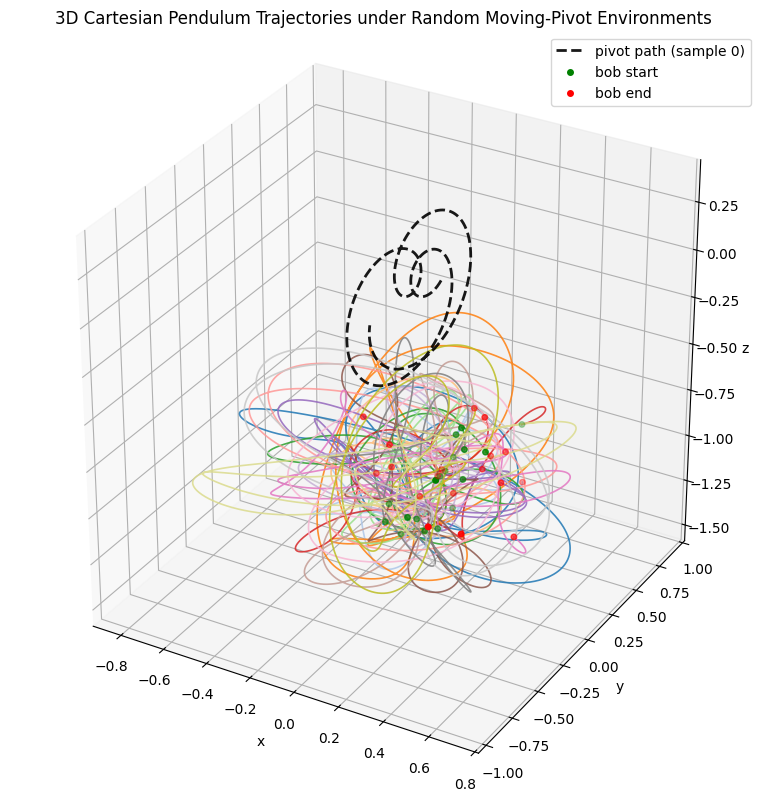

In [4]:
# Visualization 1: many trajectories in 3D (bob + pivot paths)
t = traj["t"]
r = traj["r"]
a = traj["a"]

rng = np.random.default_rng(0)
idx = rng.choice(r.shape[0], size=min(18, r.shape[0]), replace=False)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for k, i in enumerate(idx):
    color = plt.cm.tab20(k % 20)
    ax.plot(r[i, :, 0], r[i, :, 1], r[i, :, 2], color=color, lw=1.2, alpha=0.85)

ax.plot(a[0, :, 0], a[0, :, 1], a[0, :, 2], "k--", lw=2.0, alpha=0.9, label="pivot path (sample 0)")
ax.scatter(r[idx, 0, 0], r[idx, 0, 1], r[idx, 0, 2], s=16, c="green", label="bob start")
ax.scatter(r[idx, -1, 0], r[idx, -1, 1], r[idx, -1, 2], s=16, c="red", label="bob end")

ax.set_title("3D Cartesian Pendulum Trajectories under Random Moving-Pivot Environments")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend(loc="upper right")
ax.set_box_aspect((1, 1, 1))
plt.tight_layout()
plt.show()


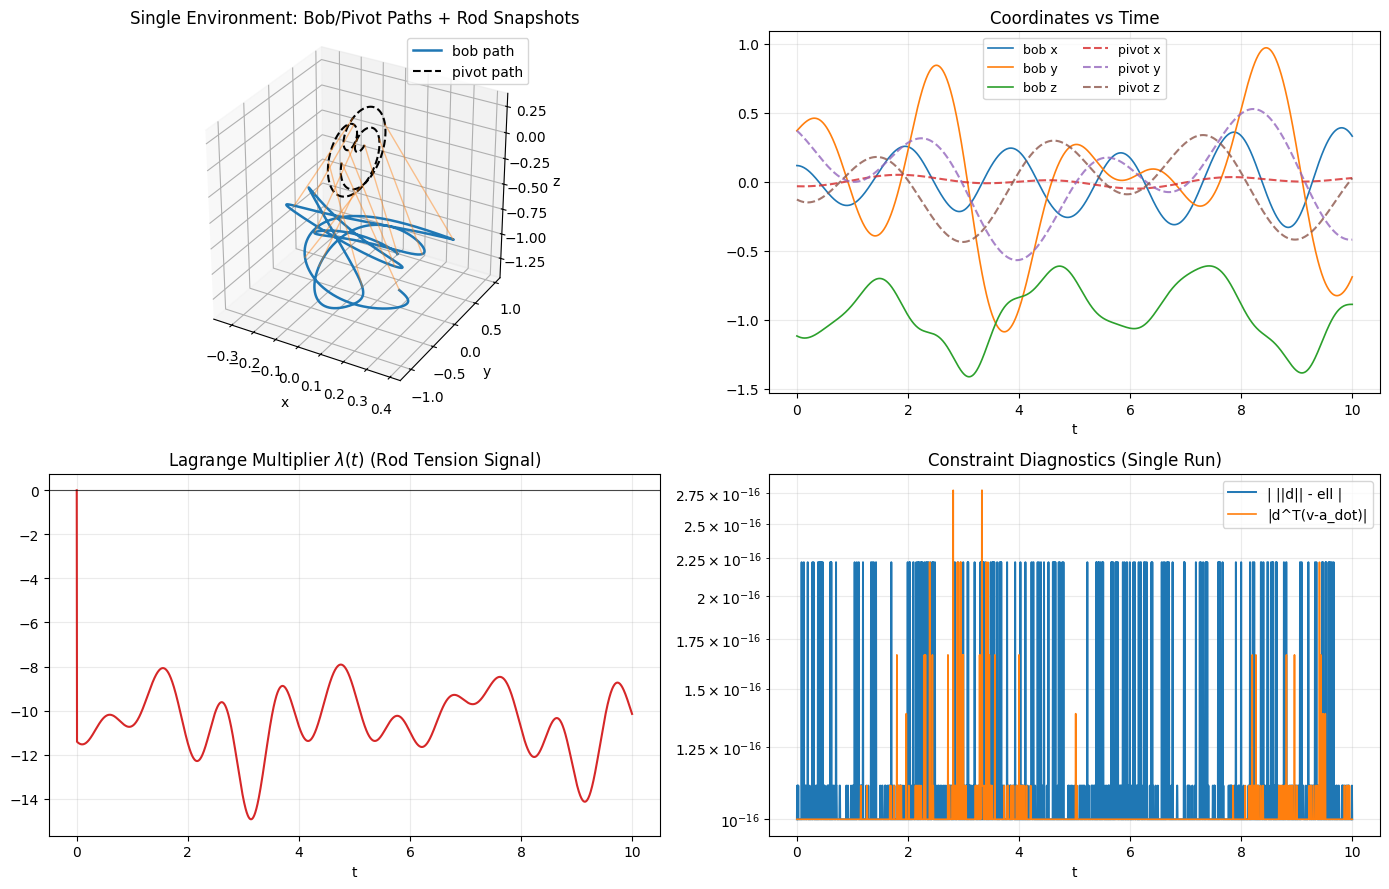

In [5]:
# Visualization 2: single trajectory with rod snapshots + time diagnostics
i = 0
t = traj["t"]
r0 = traj["r"][i]
a0_hist = traj["a"][i]
lam0 = traj["lambda"][i]
cerr0 = traj["constraint_err"][i]
terr0 = traj["tangency_err"][i]

fig = plt.figure(figsize=(14, 9))
ax3d = fig.add_subplot(2, 2, 1, projection="3d")
ax3d.plot(r0[:, 0], r0[:, 1], r0[:, 2], color="tab:blue", lw=1.8, label="bob path")
ax3d.plot(a0_hist[:, 0], a0_hist[:, 1], a0_hist[:, 2], "k--", lw=1.5, label="pivot path")

snap_ids = np.linspace(0, len(t) - 1, 11, dtype=int)
for j in snap_ids:
    ax3d.plot([a0_hist[j, 0], r0[j, 0]], [a0_hist[j, 1], r0[j, 1]], [a0_hist[j, 2], r0[j, 2]],
              color="tab:orange", alpha=0.45, lw=1.0)

ax3d.set_title("Single Environment: Bob/Pivot Paths + Rod Snapshots")
ax3d.set_xlabel("x")
ax3d.set_ylabel("y")
ax3d.set_zlabel("z")
ax3d.legend(loc="upper right")
ax3d.set_box_aspect((1, 1, 1))

ax_pos = fig.add_subplot(2, 2, 2)
ax_pos.plot(t, r0[:, 0], label="bob x", lw=1.2)
ax_pos.plot(t, r0[:, 1], label="bob y", lw=1.2)
ax_pos.plot(t, r0[:, 2], label="bob z", lw=1.2)
ax_pos.plot(t, a0_hist[:, 0], "--", label="pivot x", alpha=0.8)
ax_pos.plot(t, a0_hist[:, 1], "--", label="pivot y", alpha=0.8)
ax_pos.plot(t, a0_hist[:, 2], "--", label="pivot z", alpha=0.8)
ax_pos.set_title("Coordinates vs Time")
ax_pos.set_xlabel("t")
ax_pos.grid(True, alpha=0.25)
ax_pos.legend(ncol=2, fontsize=9)

ax_lam = fig.add_subplot(2, 2, 3)
ax_lam.plot(t, lam0, color="tab:red", lw=1.5)
ax_lam.axhline(0.0, color="k", lw=0.8, alpha=0.7)
ax_lam.set_title(r"Lagrange Multiplier $\lambda(t)$ (Rod Tension Signal)")
ax_lam.set_xlabel("t")
ax_lam.grid(True, alpha=0.25)

ax_err = fig.add_subplot(2, 2, 4)
ax_err.semilogy(t, np.maximum(cerr0, 1e-16), label="| ||d|| - ell |", lw=1.4)
ax_err.semilogy(t, np.maximum(np.abs(terr0), 1e-16), label="|d^T(v-a_dot)|", lw=1.2)
ax_err.set_title("Constraint Diagnostics (Single Run)")
ax_err.set_xlabel("t")
ax_err.grid(True, which="both", alpha=0.25)
ax_err.legend()

plt.tight_layout()
plt.show()


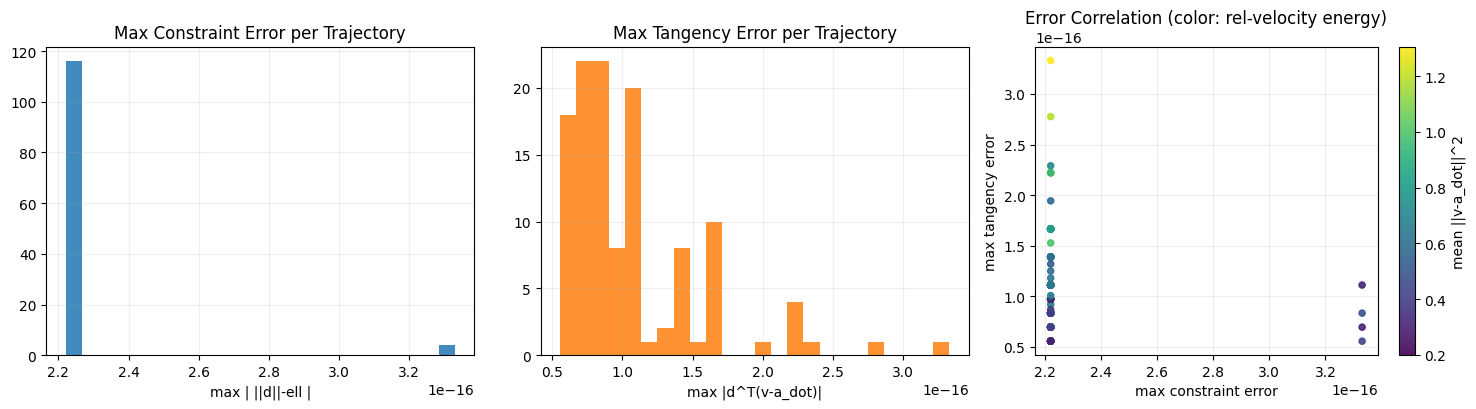

Dataset-level stats:
  median max constraint error: 2.220446049250313e-16
  median max tangency error: 8.326672684688674e-17


In [6]:
# Visualization 3: population-level diagnostics across sampled environments
max_cerr = np.max(traj["constraint_err"], axis=1)
max_terr = np.max(np.abs(traj["tangency_err"]), axis=1)
energy_like = np.mean(np.linalg.norm(traj["v"] - np.gradient(traj["a"], traj["t"], axis=1), axis=2) ** 2, axis=1)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].hist(max_cerr, bins=24, color="tab:blue", alpha=0.85)
ax[0].set_title("Max Constraint Error per Trajectory")
ax[0].set_xlabel("max | ||d||-ell |")
ax[0].grid(True, alpha=0.2)

ax[1].hist(max_terr, bins=24, color="tab:orange", alpha=0.85)
ax[1].set_title("Max Tangency Error per Trajectory")
ax[1].set_xlabel("max |d^T(v-a_dot)|")
ax[1].grid(True, alpha=0.2)

sc = ax[2].scatter(max_cerr, max_terr, c=energy_like, cmap="viridis", s=20, alpha=0.9)
ax[2].set_title("Error Correlation (color: rel-velocity energy)")
ax[2].set_xlabel("max constraint error")
ax[2].set_ylabel("max tangency error")
ax[2].grid(True, alpha=0.2)
fig.colorbar(sc, ax=ax[2], label="mean ||v-a_dot||^2")

plt.tight_layout()
plt.show()

print("Dataset-level stats:")
print("  median max constraint error:", np.median(max_cerr))
print("  median max tangency error:", np.median(max_terr))


In [ ]:
# Extra pivot trajectory families from your suggestion
def pivot_planar_circle(t, a0, A=0.35, omega=1.2, phi=0.0, R=np.eye(3)):
    t = np.asarray(t, dtype=float)
    base = np.column_stack([A*np.cos(omega*t + phi), A*np.sin(omega*t + phi), np.zeros_like(t)])
    return a0[None, :] + base @ np.asarray(R, dtype=float).T


def pivot_circle_plus_heave(t, a0, A=0.35, B=0.08, omega=1.2, phi_z=np.pi/2, R=np.eye(3)):
    t = np.asarray(t, dtype=float)
    base = np.column_stack([A*np.cos(omega*t), A*np.sin(omega*t), B*np.sin(omega*t + phi_z)])
    return a0[None, :] + base @ np.asarray(R, dtype=float).T


def _plot_pivot_family(t, a, title):
    fig = plt.figure(figsize=(12, 5))
    ax3d = fig.add_subplot(1, 2, 1, projection="3d")
    ax3d.plot(a[:, 0], a[:, 1], a[:, 2], lw=2.2, color="tab:blue")
    ax3d.scatter(a[0, 0], a[0, 1], a[0, 2], c="green", s=30, label="start")
    ax3d.scatter(a[-1, 0], a[-1, 1], a[-1, 2], c="red", s=30, label="end")
    ax3d.set_title(title + " (3D path)")
    ax3d.set_xlabel("x")
    ax3d.set_ylabel("y")
    ax3d.set_zlabel("z")
    ax3d.legend()
    ax3d.set_box_aspect((1, 1, 1))

    ax = fig.add_subplot(1, 2, 2)
    ax.plot(t, a[:, 0], label="a_x", lw=1.6)
    ax.plot(t, a[:, 1], label="a_y", lw=1.6)
    ax.plot(t, a[:, 2], label="a_z", lw=1.6)
    ax.set_title(title + " (components vs time)")
    ax.set_xlabel("t")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
# Visualize the two a(t) families
t_vis = np.linspace(0.0, 16.0, 2000)
a0_vis = np.array([0.0, 0.0, 0.0])

# 2) Planar circle
a_circle = pivot_planar_circle(t_vis, a0=a0_vis, A=0.35, omega=1.2, phi=0.35)
_plot_pivot_family(t_vis, a_circle, "Planar Circle Pivot")

# 4) Circle + vertical heave (B << A)
a_heave = pivot_circle_plus_heave(t_vis, a0=a0_vis, A=0.35, B=0.06, omega=1.2, phi_z=np.pi/2)
_plot_pivot_family(t_vis, a_heave, "Circle + Vertical Heave Pivot")


In [ ]:
# Helpers: sample X and evaluate pivot families in batch
def sample_X_planar_circle(n_samples, A_range=(0.22, 0.42), omega_range=(0.8, 1.8), seed=0):
    rng = np.random.default_rng(seed)
    A = rng.uniform(*A_range, size=n_samples)
    omega = rng.uniform(*omega_range, size=n_samples)
    phi = rng.uniform(0.0, 2.0*np.pi, size=n_samples)
    return np.column_stack([A, omega, phi])


def sample_X_circle_heave(n_samples, A_range=(0.22, 0.42), B_range=(0.02, 0.08), omega_range=(0.8, 1.8), seed=1):
    rng = np.random.default_rng(seed)
    A = rng.uniform(*A_range, size=n_samples)
    B = rng.uniform(*B_range, size=n_samples)
    omega = rng.uniform(*omega_range, size=n_samples)
    phi_z = rng.uniform(0.0, 2.0*np.pi, size=n_samples)
    return np.column_stack([A, B, omega, phi_z])


def pivot_planar_circle_batch(t, X, a0=np.zeros(3), R=np.eye(3)):
    X = np.asarray(X, dtype=float)
    A, omega, phi = X[:, 0], X[:, 1], X[:, 2]
    th = omega * t + phi

    base = np.column_stack([A * np.cos(th), A * np.sin(th), np.zeros_like(A)])
    base_dot = np.column_stack([-A * omega * np.sin(th), A * omega * np.cos(th), np.zeros_like(A)])
    base_ddot = np.column_stack([-A * (omega**2) * np.cos(th), -A * (omega**2) * np.sin(th), np.zeros_like(A)])

    R = np.asarray(R, dtype=float)
    a = a0[None, :] + base @ R.T
    a_dot = base_dot @ R.T
    a_ddot = base_ddot @ R.T
    return a, a_dot, a_ddot


def pivot_circle_heave_batch(t, X, a0=np.zeros(3), R=np.eye(3)):
    X = np.asarray(X, dtype=float)
    A, B, omega, phi_z = X[:, 0], X[:, 1], X[:, 2], X[:, 3]
    th = omega * t

    base = np.column_stack([A * np.cos(th), A * np.sin(th), B * np.sin(th + phi_z)])
    base_dot = np.column_stack([-A * omega * np.sin(th), A * omega * np.cos(th), B * omega * np.cos(th + phi_z)])
    base_ddot = np.column_stack([-A * (omega**2) * np.cos(th), -A * (omega**2) * np.sin(th), -B * (omega**2) * np.sin(th + phi_z)])

    R = np.asarray(R, dtype=float)
    a = a0[None, :] + base @ R.T
    a_dot = base_dot @ R.T
    a_ddot = base_ddot @ R.T
    return a, a_dot, a_ddot


In [31]:
# Generic simulator for custom pivot parameterizations a(t;X)
def simulate_cartesian_pendulum_custom(
    params, t_final, dt, X, pivot_eval,
    n0=np.array([0.15, 0.0, -0.9887]), rel_v0=np.array([0.0, 0.8, 0.0]),
    project_each_step=True,
):
    params.validate()
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X[None, :]

    N = X.shape[0]
    n_steps = int(np.floor(t_final / dt))
    t = np.linspace(0.0, n_steps * dt, n_steps + 1)

    n0 = np.asarray(n0, dtype=float)
    n0 = n0 / np.linalg.norm(n0)
    rel_v0 = np.asarray(rel_v0, dtype=float)

    r = np.zeros((N, t.size, 3), dtype=float)
    v = np.zeros((N, t.size, 3), dtype=float)
    a_hist = np.zeros((N, t.size, 3), dtype=float)

    a_init, a_dot_init, _ = pivot_eval(t[0], X)
    a_hist[:, 0] = a_init
    r[:, 0] = a_init + params.length * n0[None, :]

    rel_v = np.broadcast_to(rel_v0, (N, 3)).astype(float).copy()
    d0 = r[:, 0] - a_init
    rel_v -= ((np.einsum("ij,ij->i", d0, rel_v) / (params.length**2))[:, None]) * d0
    v[:, 0] = a_dot_init + rel_v

    g0 = np.array([0.0, 0.0, -params.gravity], dtype=float)

    def rhs(ti, ri, vi):
        ai, ai_dot, ai_ddot = pivot_eval(ti, X)
        d = ri - ai
        rel_vi = vi - ai_dot
        lam = _lambda_closed_form(params, d=d, rel_v=rel_vi, a_ddot=ai_ddot)
        dr = vi
        dv = g0[None, :] + (lam[:, None] / params.mass) * d
        return dr, dv

    for i in range(n_steps):
        ti = t[i]
        ri = r[:, i]
        vi = v[:, i]

        k1_r, k1_v = rhs(ti, ri, vi)
        k2_r, k2_v = rhs(ti + 0.5 * dt, ri + 0.5 * dt * k1_r, vi + 0.5 * dt * k1_v)
        k3_r, k3_v = rhs(ti + 0.5 * dt, ri + 0.5 * dt * k2_r, vi + 0.5 * dt * k2_v)
        k4_r, k4_v = rhs(ti + dt, ri + dt * k3_r, vi + dt * k3_v)

        r_next = ri + (dt / 6.0) * (k1_r + 2.0 * k2_r + 2.0 * k3_r + k4_r)
        v_next = vi + (dt / 6.0) * (k1_v + 2.0 * k2_v + 2.0 * k3_v + k4_v)

        a_next, a_dot_next, _ = pivot_eval(t[i + 1], X)

        if project_each_step:
            d = r_next - a_next
            d_norm = np.linalg.norm(d, axis=1, keepdims=True)
            d = params.length * d / np.maximum(d_norm, 1e-12)
            r_next = a_next + d

            rel_v_next = v_next - a_dot_next
            rel_v_next -= ((np.einsum("ij,ij->i", d, rel_v_next) / (params.length**2))[:, None]) * d
            v_next = a_dot_next + rel_v_next

        r[:, i + 1] = r_next
        v[:, i + 1] = v_next
        a_hist[:, i + 1] = a_next

    return {"t": t, "r": r, "v": v, "a": a_hist, "X": X}


def _draw_reference_cone(ax, apex, theta_max_deg=25.0, cone_height=1.2, color="gray", alpha=0.12):
    theta = np.deg2rad(theta_max_deg)
    phi = np.linspace(0.0, 2.0 * np.pi, 48)
    h = np.linspace(0.0, cone_height, 24)
    P, H = np.meshgrid(phi, h)
    R = H * np.tan(theta)

    Xc = apex[0] + R * np.cos(P)
    Yc = apex[1] + R * np.sin(P)
    Zc = apex[2] - H
    ax.plot_surface(Xc, Yc, Zc, color=color, alpha=alpha, linewidth=0, shade=False)


def plot_many_3d_like_you_prefer(traj, title, theta_max_deg=25.0):
    t = traj["t"]
    r = traj["r"]
    a = traj["a"]

    d = r - a
    d_norm = np.linalg.norm(d, axis=2, keepdims=True)
    u = d / np.maximum(d_norm, 1e-12)
    safe_mask = (-u[:, :, 2]) >= np.cos(np.deg2rad(theta_max_deg))
    is_stable = np.all(safe_mask, axis=1)

    rng = np.random.default_rng(0)
    idx = rng.choice(r.shape[0], size=min(18, r.shape[0]), replace=False)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    ell_est = float(np.median(np.linalg.norm(d, axis=2)))
    apex = a[0, 0]
    _draw_reference_cone(ax, apex=apex, theta_max_deg=theta_max_deg, cone_height=1.2 * ell_est)

    unstable_count = 0
    for k, i in enumerate(idx):
        if is_stable[i]:
            color = plt.cm.tab20(k % 20)
            lw = 1.2
            alpha = 0.85
        else:
            color = "crimson"
            lw = 1.8
            alpha = 0.95
            unstable_count += 1
        ax.plot(r[i, :, 0], r[i, :, 1], r[i, :, 2], color=color, lw=lw, alpha=alpha)

    ax.plot(a[0, :, 0], a[0, :, 1], a[0, :, 2], "k--", lw=2.0, alpha=0.9, label="pivot path (sample 0)")
    ax.scatter(r[idx, 0, 0], r[idx, 0, 1], r[idx, 0, 2], s=16, c="green", label="bob start")
    ax.scatter(r[idx, -1, 0], r[idx, -1, 1], r[idx, -1, 2], s=16, c="red", label="bob end")

    ax.set_title(f"{title} | cone angle <= {theta_max_deg:.1f} deg | unstable shown in red")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend(loc="upper right")
    ax.text2D(0.02, 0.98, f"unstable among plotted: {unstable_count}/{len(idx)}", transform=ax.transAxes)
    ax.set_box_aspect((1, 1, 1))
    plt.tight_layout()
    plt.show()



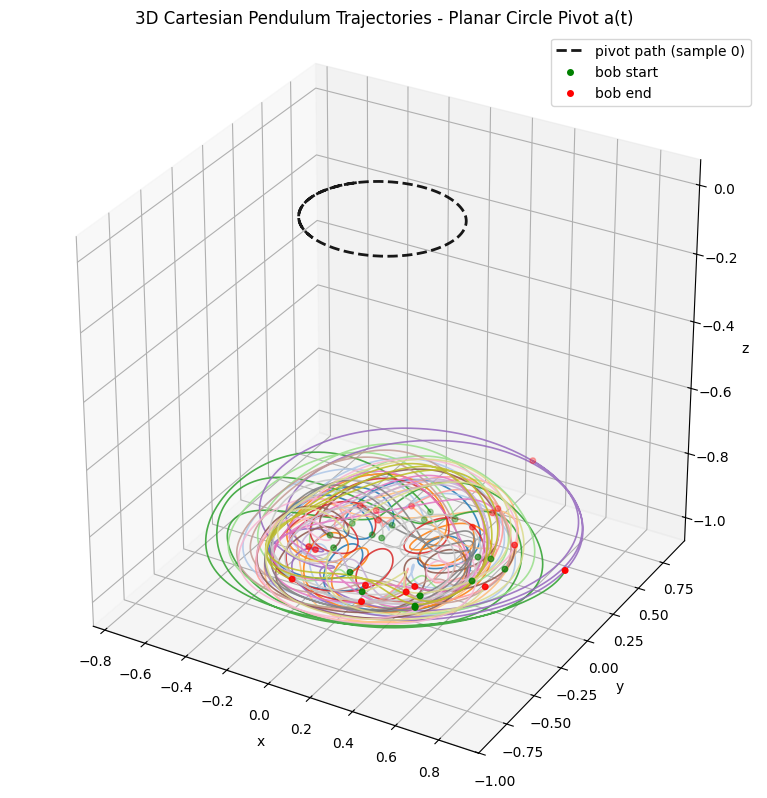

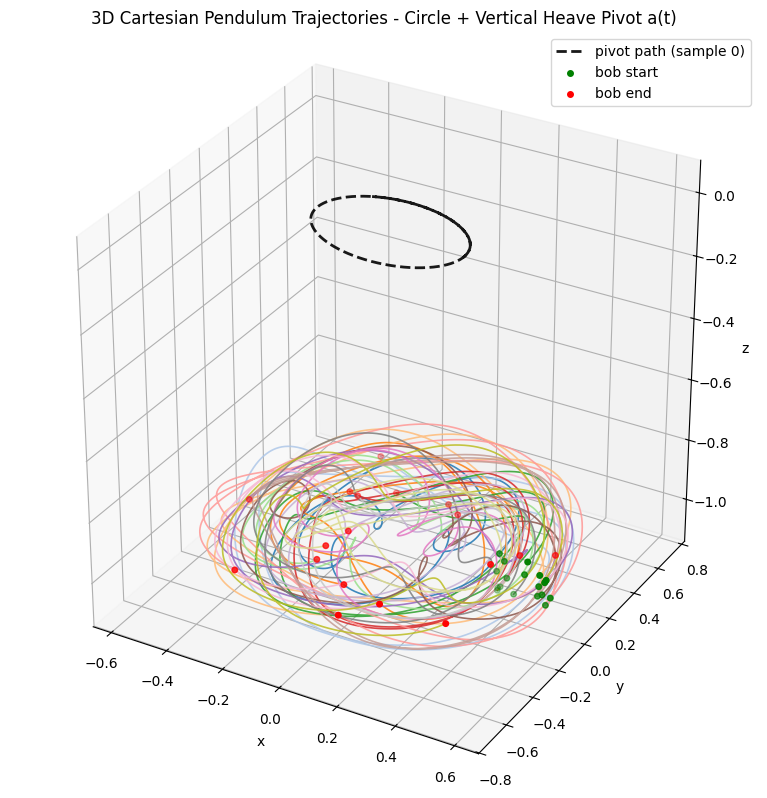

In [27]:
# End plots: same style for each pivot a(t) parameterization
N_family = 120
T_family = 10.0
dt_family = 0.005

X_planar = sample_X_planar_circle(N_family, seed=7)
traj_planar = simulate_cartesian_pendulum_custom(
    params=params,
    t_final=T_family,
    dt=dt_family,
    X=X_planar,
    pivot_eval=lambda t_, X_: pivot_planar_circle_batch(t_, X_, a0=np.array([0.0, 0.0, 0.0])),
)
plot_many_3d_like_you_prefer(
    traj_planar,
    "3D Cartesian Pendulum Trajectories - Planar Circle Pivot a(t)"
)

X_heave = sample_X_circle_heave(N_family, seed=11)
traj_heave = simulate_cartesian_pendulum_custom(
    params=params,
    t_final=T_family,
    dt=dt_family,
    X=X_heave,
    pivot_eval=lambda t_, X_: pivot_circle_heave_batch(t_, X_, a0=np.array([0.0, 0.0, 0.0])),
)
plot_many_3d_like_you_prefer(
    traj_heave,
    "3D Cartesian Pendulum Trajectories - Circle + Vertical Heave Pivot a(t)"
)


In [28]:
# Family 3: transient smooth pulse shake (Gaussian-windowed sinusoid)
def sample_X_shake_pulse(
    n_samples,
    A_range=(0.10, 0.35),
    omega_range=(1.0, 3.0),
    tau_range=(0.45, 1.2),
    t0=None,
    q=np.array([1.0, 0.0, 0.0]),
    a0=np.array([0.0, 0.0, 0.0]),
    seed=21,
):
    rng = np.random.default_rng(seed)
    A = rng.uniform(*A_range, size=n_samples)
    omega = rng.uniform(*omega_range, size=n_samples)
    tau = rng.uniform(*tau_range, size=n_samples)
    if t0 is None:
        t0_vals = np.full(n_samples, np.nan)
    else:
        t0_vals = np.full(n_samples, float(t0))

    q = np.asarray(q, dtype=float)
    q = q / np.linalg.norm(q)
    a0 = np.asarray(a0, dtype=float)

    q_all = np.tile(q[None, :], (n_samples, 1))
    a0_all = np.tile(a0[None, :], (n_samples, 1))

    # X columns: [A, omega, tau, t0, qx, qy, qz, a0x, a0y, a0z]
    return np.column_stack([A, omega, tau, t0_vals, q_all, a0_all])


def pivot_shake_pulse_batch(t, X):
    X = np.asarray(X, dtype=float)
    A = X[:, 0]
    omega = X[:, 1]
    tau = np.maximum(X[:, 2], 1e-6)
    t0 = X[:, 3].copy()
    q = X[:, 4:7]
    a0 = X[:, 7:10]

    q_norm = np.linalg.norm(q, axis=1, keepdims=True)
    q = q / np.maximum(q_norm, 1e-12)

    # Allow NaN t0 in X: if NaN, set default event center at t=5.0
    t0 = np.where(np.isnan(t0), 5.0, t0)

    s = t - t0
    env = np.exp(-(s**2) / (2.0 * tau**2))
    sin_term = np.sin(omega * s)
    cos_term = np.cos(omega * s)

    amp = A * env * sin_term
    amp_dot = A * env * ((-s / (tau**2)) * sin_term + omega * cos_term)
    amp_ddot = A * env * ((s**2 / (tau**4) - 1.0 / (tau**2) - omega**2) * sin_term - 2.0 * omega * s / (tau**2) * cos_term)

    a = a0 + amp[:, None] * q
    a_dot = amp_dot[:, None] * q
    a_ddot = amp_ddot[:, None] * q
    return a, a_dot, a_ddot


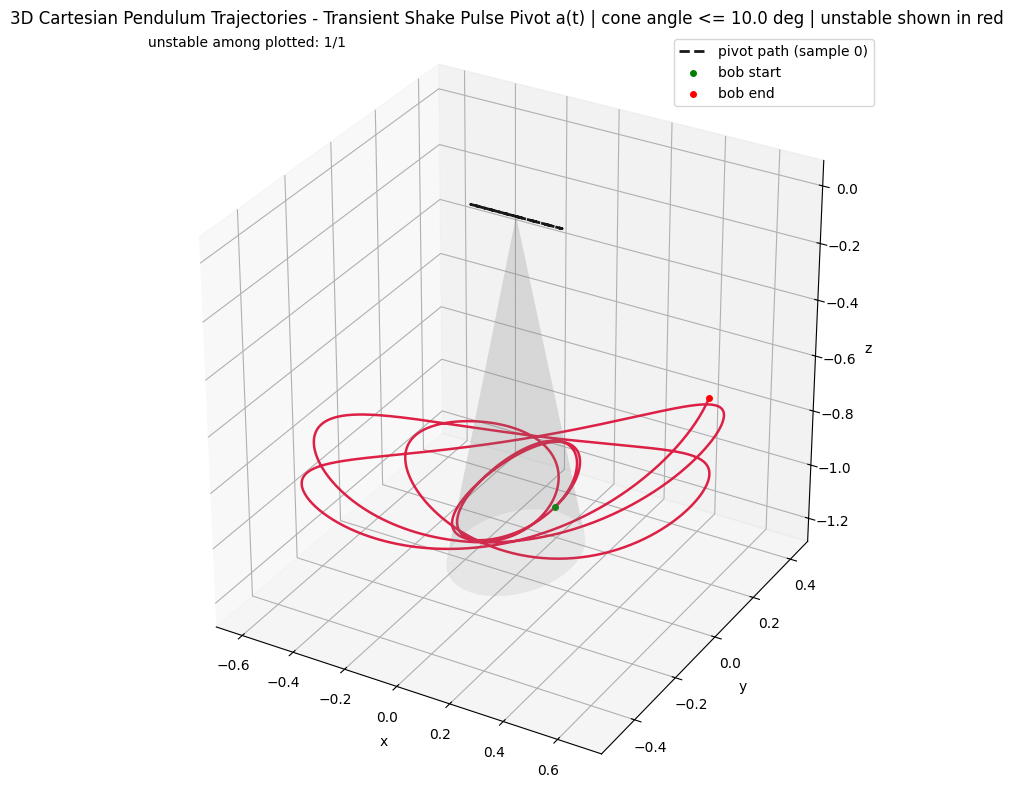

In [ ]:
# End plot: same style for the transient shake-event family
N_pulse = 1
T_pulse = 10.0
dt_pulse = 0.005
t0_pulse = T_pulse / 2.0

X_pulse = sample_X_shake_pulse(
    N_pulse,
    A_range=(0.10, 0.30),
    omega_range=(1.0, 2.8),
    tau_range=(0.5, 2.5),
    t0=t0_pulse,
    q=np.array([1.0, 0.0, 0.0]),
    a0=np.array([0.0, 0.0, 0.0]),
    seed=23,
)

traj_pulse = simulate_cartesian_pendulum_custom(
    params=params,
    t_final=T_pulse,
    dt=dt_pulse,
    X=X_pulse,
    pivot_eval=pivot_shake_pulse_batch,
)
theta_max_deg=25
plot_many_3d_like_you_prefer(
    traj_pulse,
    "3D Cartesian Pendulum Trajectories - Transient Shake Pulse Pivot a(t)",
    theta_max_deg=theta_max_deg
)



In [54]:
# GIF animation for one transient-shake trajectory
from matplotlib.animation import FuncAnimation, PillowWriter

def save_single_traj_gif(traj, out_path=None, fps=30, stride=6, trail=160, theta_max_deg=25.0):
    if out_path is None:
        out_path = Path.cwd().resolve() / "figure" / "transient_shake_single_traj.gif"
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    t = traj["t"]
    r = traj["r"][0]  # single trajectory
    a = traj["a"][0]
    apex_fixed = a[0].copy()

    d = r - a
    ell_est = float(np.median(np.linalg.norm(d, axis=1)))

    frame_ids = np.arange(0, len(t), stride, dtype=int)
    if frame_ids[-1] != len(t) - 1:
        frame_ids = np.append(frame_ids, len(t) - 1)

    xyz_all = np.vstack([r, a])
    mins = xyz_all.min(axis=0)
    maxs = xyz_all.max(axis=0)
    center = 0.5 * (mins + maxs)
    radius = 0.6 * np.max(maxs - mins) + 0.25

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title("Transient Shake Pendulum (single trajectory)")

    pivot_line, = ax.plot([], [], [], "k--", lw=1.4, alpha=0.85, label="pivot path")
    bob_trail, = ax.plot([], [], [], color="tab:blue", lw=1.6, alpha=0.9, label="bob trail")
    rod_line, = ax.plot([], [], [], color="tab:orange", lw=2.2, label="rod")
    pivot_dot = ax.scatter([], [], [], color="black", s=30)
    bob_dot = ax.scatter([], [], [], color="tab:blue", s=36)

    # Cone wireframe artists (updated each frame around current pivot)
    n_rays = 12
    ray_lines = [ax.plot([], [], [], color="gray", lw=0.8, alpha=0.5)[0] for _ in range(n_rays)]
    cone_ring, = ax.plot([], [], [], color="gray", lw=1.0, alpha=0.8, label="safety cone")

    time_text = ax.text2D(0.02, 0.95, "", transform=ax.transAxes)
    status_text = ax.text2D(0.02, 0.90, "", transform=ax.transAxes)
    ax.legend(loc="upper right")

    theta = np.deg2rad(theta_max_deg)
    cone_h = 1.2 * ell_est
    cone_r = cone_h * np.tan(theta)
    ring_phi = np.linspace(0.0, 2.0 * np.pi, 200)

    def _set_scatter(sc, x, y, z):
        sc._offsets3d = ([x], [y], [z])

    def init():
        pivot_line.set_data([], [])
        pivot_line.set_3d_properties([])
        bob_trail.set_data([], [])
        bob_trail.set_3d_properties([])
        rod_line.set_data([], [])
        rod_line.set_3d_properties([])
        cone_ring.set_data([], [])
        cone_ring.set_3d_properties([])
        for rl in ray_lines:
            rl.set_data([], [])
            rl.set_3d_properties([])
        time_text.set_text("")
        status_text.set_text("")
        return (pivot_line, bob_trail, rod_line, pivot_dot, bob_dot, cone_ring, *ray_lines, time_text, status_text)

    def update(fi):
        j = frame_ids[fi]
        j0 = max(0, j - trail)

        pivot_line.set_data(a[: j + 1, 0], a[: j + 1, 1])
        pivot_line.set_3d_properties(a[: j + 1, 2])

        bob_trail.set_data(r[j0 : j + 1, 0], r[j0 : j + 1, 1])
        bob_trail.set_3d_properties(r[j0 : j + 1, 2])

        rod_line.set_data([a[j, 0], r[j, 0]], [a[j, 1], r[j, 1]])
        rod_line.set_3d_properties([a[j, 2], r[j, 2]])

        # Update moving cone anchored at pivot a[j]
        cx = apex_fixed[0] + cone_r * np.cos(ring_phi)
        cy = apex_fixed[1] + cone_r * np.sin(ring_phi)
        cz = np.full_like(cx, apex_fixed[2] - cone_h)
        cone_ring.set_data(cx, cy)
        cone_ring.set_3d_properties(cz)

        ray_phi = np.linspace(0.0, 2.0 * np.pi, n_rays, endpoint=False)
        for k, ph in enumerate(ray_phi):
            bx = apex_fixed[0] + cone_r * np.cos(ph)
            by = apex_fixed[1] + cone_r * np.sin(ph)
            bz = apex_fixed[2] - cone_h
            ray_lines[k].set_data([apex_fixed[0], bx], [apex_fixed[1], by])
            ray_lines[k].set_3d_properties([apex_fixed[2], bz])

        _set_scatter(pivot_dot, a[j, 0], a[j, 1], a[j, 2])
        _set_scatter(bob_dot, r[j, 0], r[j, 1], r[j, 2])

        u = (r[j] - a[j]) / max(np.linalg.norm(r[j] - a[j]), 1e-12)
        safe_now = (-u[2]) >= np.cos(theta)
        bob_dot._facecolor3d = ("tab:blue" if safe_now else "crimson")
        bob_dot._edgecolor3d = ("tab:blue" if safe_now else "crimson")

        time_text.set_text(f"t = {t[j]:.2f} s")
        status_text.set_text(f"status: {'SAFE' if safe_now else 'UNSAFE'}")
        status_text.set_color("tab:green" if safe_now else "crimson")
        return (pivot_line, bob_trail, rod_line, pivot_dot, bob_dot, cone_ring, *ray_lines, time_text, status_text)

    ani = FuncAnimation(fig, update, frames=len(frame_ids), init_func=init, interval=1000.0/fps, blit=False)
    ani.save(out_path, writer=PillowWriter(fps=fps))
    plt.close(fig)
    print(f"Saved GIF: {out_path}")
    return out_path

gif_path = save_single_traj_gif(traj_pulse, fps=30, stride=6, trail=180, theta_max_deg=theta_max_deg)





Saved GIF: /home/mzheng/research/Physics-Informed-Hypo-Test/notebook/figure/transient_shake_single_traj.gif


In [90]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [105]:
# Multiple GIF variants with stronger safety/instability visibility
from matplotlib.animation import FuncAnimation, PillowWriter

def _cone_geom(apex, theta_rad, cone_h, n_ring=200):
    ring_phi = np.linspace(0.0, 2.0*np.pi, n_ring)
    cone_r = cone_h * np.tan(theta_rad)
    cx = apex[0] + cone_r*np.cos(ring_phi)
    cy = apex[1] + cone_r*np.sin(ring_phi)
    cz = np.full_like(cx, apex[2] - cone_h)
    return cx, cy, cz, cone_r


def _safe_mask_single(traj, theta_max_deg=25.0):
    r = traj['r'][0]
    a = traj['a'][0]
    apex_fixed = a[0].copy()
    d = r - a
    u = d / np.maximum(np.linalg.norm(d, axis=1, keepdims=True), 1e-12)
    m = -u[:, 2] - np.cos(np.deg2rad(theta_max_deg))
    safe = m >= 0.0
    return safe, m


def gif_variant_latch_banner(traj, out_path, theta_max_deg=25.0, fps=30, stride=6, trail=180, show_all_top_paths=True):
    t = traj['t']
    r_all = traj['r']
    a_all = traj['a']

    r = r_all[0]
    a = a_all[0]
    apex_fixed = a[0].copy()
    safe, m = _safe_mask_single({'t': t, 'r': r_all[:1], 'a': a_all[:1]}, theta_max_deg=theta_max_deg)

    d = r - a
    u = d / np.maximum(np.linalg.norm(d, axis=1, keepdims=True), 1e-12)
    theta_deg = np.degrees(np.arccos(np.clip(-u[:, 2], -1.0, 1.0)))

    frame_ids = list(np.arange(0, len(t), stride, dtype=int))
    if frame_ids[-1] != len(t)-1:
        frame_ids.append(len(t)-1)

    xyz_all = np.vstack([r, a])
    mins = xyz_all.min(axis=0); maxs = xyz_all.max(axis=0)
    center = 0.5*(mins+maxs); radius = 0.6*np.max(maxs-mins) + 0.25
    ell = float(np.median(np.linalg.norm(r-a, axis=1)))

    # 3-panel layout: 3D (left), theta diagnostic (middle), top view (right)
    fig = plt.figure(figsize=(16.2, 6.0))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.55, 1.0, 1.05])
    ax = fig.add_subplot(gs[0, 0], projection='3d')
    axd = fig.add_subplot(gs[0, 1])
    axt = fig.add_subplot(gs[0, 2])

    # Middle diagnostic subplot: theta(t) and threshold
    axd.plot(t, theta_deg, color='black', lw=1.9, label=r'$\varphi(t;X)$')
    axd.axhline(theta_max_deg, color='crimson', lw=2.0, linestyle='--', label=r'$\tau$')
    axd.fill_between(t, theta_deg, theta_max_deg, where=(theta_deg >= theta_max_deg), color='crimson', alpha=0.15)
    marker_theta, = axd.plot([], [], 'o', color='tab:blue', ms=7)
    vline = axd.axvline(0.0, color='tab:blue', lw=1.2, alpha=0.9)
    axd.set_title('Swing Angle vs Threshold', fontsize=12)
    axd.set_xlabel('time [s]')
    axd.set_ylabel(r'$\varphi$ [deg]')
    axd.grid(True, alpha=0.25)
    axd.legend(loc='upper right', fontsize=9)

    # Right top-view subplot: full trajectories + safety circle at a(0)
    cone_h = 1.2 * ell
    safe_radius_xy = cone_h * np.tan(np.deg2rad(theta_max_deg))
    pivot_x, pivot_y = apex_fixed[0], apex_fixed[1]

    axt.set_title('Top View (x-y): Trajectories vs Safety Radius', fontsize=12)
    axt.set_xlabel('x')
    axt.set_ylabel('y')
    axt.grid(True, alpha=0.25)
    axt.set_aspect('equal', adjustable='box')

    all_xy = np.vstack([r_all.reshape(-1, 3)[:, :2], a_all.reshape(-1, 3)[:, :2], np.array([[pivot_x + safe_radius_xy, pivot_y], [pivot_x - safe_radius_xy, pivot_y], [pivot_x, pivot_y + safe_radius_xy], [pivot_x, pivot_y - safe_radius_xy]])])
    min_xy = all_xy.min(axis=0)
    max_xy = all_xy.max(axis=0)
    pad_xy = 0.08 * np.max(max_xy - min_xy) + 0.05
    axt.set_xlim(min_xy[0] - pad_xy, max_xy[0] + pad_xy)
    axt.set_ylim(min_xy[1] - pad_xy, max_xy[1] + pad_xy)

    circle = plt.Circle((pivot_x, pivot_y), safe_radius_xy, edgecolor='black', facecolor='none', linestyle='--', linewidth=1.8, alpha=0.9)
    axt.add_patch(circle)
    axt.scatter([pivot_x], [pivot_y], c='k', s=30, label=r'u(0;X)')

    # static background: all trajectories (if available)
    if show_all_top_paths and r_all.shape[0] > 1:
        for i in range(r_all.shape[0]):
            axt.plot(r_all[i, :, 0], r_all[i, :, 1], color='0.82', lw=0.8, alpha=0.6)

    # highlighted trajectory (sample 0)
    axt.plot(r[:, 0], r[:, 1], color='tab:blue', lw=1.2, alpha=0.45, label='sample 0 full path')
    top_trail_safe, = axt.plot([], [], color='tab:blue', lw=2.0, label='sample 0 live trail')
    top_trail_bad, = axt.plot([], [], color='crimson', lw=2.4)
    top_dot, = axt.plot([], [], 'o', color='tab:blue', ms=7)
    axt.legend(loc='upper right', fontsize=8)

    # Left 3D panel
    ax.set_xlim(center[0]-radius, center[0]+radius)
    ax.set_ylim(center[1]-radius, center[1]+radius)
    ax.set_zlim(center[2]-radius, center[2]+radius)
    ax.set_box_aspect((1,1,1))
    ax.set_title('Variant A: Cone Boundary Contact is Highlighted', fontsize=12)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')

    # add a light, fixed cone surface for clearer geometry
    cone_phi = np.linspace(0.0, 2.0*np.pi, 40)
    cone_h_samples = np.linspace(0.0, cone_h, 18)
    P, H = np.meshgrid(cone_phi, cone_h_samples)
    Rm = H * np.tan(np.deg2rad(theta_max_deg))
    Xs = apex_fixed[0] + Rm * np.cos(P)
    Ys = apex_fixed[1] + Rm * np.sin(P)
    Zs = apex_fixed[2] - H
    ax.plot_surface(Xs, Ys, Zs, color='gray', alpha=0.08, linewidth=0, shade=False)

    pivot_line, = ax.plot([], [], [], 'k--', lw=1.2, alpha=0.85, label='pivot path')
    bob_trail, = ax.plot([], [], [], color='tab:blue', lw=1.8, alpha=0.9, label='bob trail')
    rod_line, = ax.plot([], [], [], color='tab:orange', lw=2.4, label='rod')
    pivot_dot = ax.scatter([], [], [], c='k', s=26)
    bob_dot = ax.scatter([], [], [], c='tab:blue', s=48, edgecolors='none')
    bob_glow = ax.scatter([], [], [], c='none', s=230, edgecolors='none')

    cone_ring, = ax.plot([], [], [], color='gray', lw=1.0, alpha=0.85, label='safety cone')
    n_rays = 12
    ray_lines = [ax.plot([], [], [], color='gray', lw=0.8, alpha=0.5)[0] for _ in range(n_rays)]

    txt_time = ax.text2D(0.02, 0.95, '', transform=ax.transAxes)
    txt_now = ax.text2D(0.02, 0.90, '', transform=ax.transAxes)
    ax.legend(loc='upper right', fontsize=9)

    theta = np.deg2rad(theta_max_deg)

    def _set_scatter(sc, x, y, z):
        sc._offsets3d = ([x], [y], [z])

    def update(k):
        j = frame_ids[k]
        j0 = max(0, j-trail)

        # 3D updates
        pivot_line.set_data(a[:j+1,0], a[:j+1,1]); pivot_line.set_3d_properties(a[:j+1,2])
        bob_trail.set_data(r[j0:j+1,0], r[j0:j+1,1]); bob_trail.set_3d_properties(r[j0:j+1,2])
        rod_line.set_data([a[j,0], r[j,0]], [a[j,1], r[j,1]])
        rod_line.set_3d_properties([a[j,2], r[j,2]])

        cx, cy, cz, cone_r = _cone_geom(apex_fixed, theta, cone_h)
        cone_ring.set_data(cx, cy); cone_ring.set_3d_properties(cz)
        rays = np.linspace(0, 2*np.pi, n_rays, endpoint=False)
        for ii, ph in enumerate(rays):
            bx = apex_fixed[0] + cone_r*np.cos(ph); by = apex_fixed[1] + cone_r*np.sin(ph); bz = apex_fixed[2]-cone_h
            ray_lines[ii].set_data([apex_fixed[0], bx], [apex_fixed[1], by]); ray_lines[ii].set_3d_properties([apex_fixed[2], bz])

        _set_scatter(pivot_dot, a[j,0], a[j,1], a[j,2])
        _set_scatter(bob_dot, r[j,0], r[j,1], r[j,2])
        _set_scatter(bob_glow, r[j,0], r[j,1], r[j,2])

        # Top view updates (sample 0 live trail)
        idx = np.arange(j0, j+1)
        top_rad = np.sqrt((r[idx,0] - pivot_x)**2 + (r[idx,1] - pivot_y)**2)
        safe_idx = idx[top_rad <= safe_radius_xy]
        bad_idx = idx[top_rad > safe_radius_xy]
        if len(safe_idx) > 0:
            top_trail_safe.set_data(r[safe_idx,0], r[safe_idx,1])
        else:
            top_trail_safe.set_data([], [])
        if len(bad_idx) > 0:
            top_trail_bad.set_data(r[bad_idx,0], r[bad_idx,1])
        else:
            top_trail_bad.set_data([], [])
        top_dot.set_data([r[j,0]], [r[j,1]])
        top_now_bad = np.sqrt((r[j,0]-pivot_x)**2 + (r[j,1]-pivot_y)**2) > safe_radius_xy

        # Contact or exceed boundary => red emphasis
        is_contact_or_exceed = (m[j] <= 0.0)
        if not is_contact_or_exceed:
            bob_dot._facecolor3d = ('tab:blue',); bob_dot._edgecolor3d = ('tab:blue',)
            bob_glow._facecolor3d = ((0,0,0,0),); bob_glow._edgecolor3d = ((0,0,0,0),)
            rod_line.set_color('tab:orange'); rod_line.set_linewidth(2.4)
            txt_now.set_text('current: SAFE'); txt_now.set_color('tab:green')
            marker_theta.set_color('tab:blue'); vline.set_color('tab:blue')
            top_dot.set_color('crimson' if top_now_bad else 'tab:blue')
        else:
            bob_dot._facecolor3d = ('crimson',); bob_dot._edgecolor3d = ('black',)
            bob_glow._facecolor3d = ((1,0,0,0.12),); bob_glow._edgecolor3d = ((1,0,0,0.35),)
            rod_line.set_color('crimson'); rod_line.set_linewidth(3.4)
            txt_now.set_text('current: CONTACT/UNSAFE'); txt_now.set_color('crimson')
            marker_theta.set_color('crimson'); vline.set_color('crimson')
            top_dot.set_color('crimson' if top_now_bad else 'tab:blue')

        txt_time.set_text(f't = {t[j]:.2f}s | theta={theta_deg[j]:.2f} deg')

        marker_theta.set_data([t[j]], [theta_deg[j]])
        vline.set_xdata([t[j], t[j]])

        return pivot_line, bob_trail, rod_line, pivot_dot, bob_dot, bob_glow, cone_ring, *ray_lines, txt_time, txt_now, marker_theta, vline, top_trail_safe, top_trail_bad, top_dot

    ani = FuncAnimation(fig, update, frames=len(frame_ids), interval=1000/fps, blit=False)
    out_path = Path(out_path); out_path.parent.mkdir(parents=True, exist_ok=True)
    ani.save(out_path, writer=PillowWriter(fps=fps))
    plt.close(fig)
    print('Saved', out_path)


def save_variantA_static_overview(traj, out_path, theta_max_deg=25.0, show_all_top_paths=True):
    title_fs = 13
    legend_fs = 11
    axis_label_fs = 11
    tick_fs = 10

    title_y = 1.1

    t = traj['t']
    r_all = traj['r']
    a_all = traj['a']

    r = r_all[0]
    a = a_all[0]
    apex_fixed = a[0].copy()

    d = r - a
    u = d / np.maximum(np.linalg.norm(d, axis=1, keepdims=True), 1e-12)
    theta_deg = np.degrees(np.arccos(np.clip(-u[:, 2], -1.0, 1.0)))
    m = -u[:, 2] - np.cos(np.deg2rad(theta_max_deg))
    safe = m >= 0.0

    xyz_all = np.vstack([r, a])
    mins = xyz_all.min(axis=0); maxs = xyz_all.max(axis=0)
    center = 0.5*(mins+maxs); radius = 0.6*np.max(maxs-mins) + 0.25
    ell = float(np.median(np.linalg.norm(r-a, axis=1)))
    cone_h = 1.2 * ell
    safe_radius_xy = cone_h * np.tan(np.deg2rad(theta_max_deg))

    fig = plt.figure(figsize=(18.8, 6.2), constrained_layout=False)
    gs = fig.add_gridspec(
        1, 3,
        width_ratios=[1, 1, 1],   # same subfigure size
        left=0.04, right=0.99,
        bottom=0.10, top=0.92,
        wspace=0.22               # same gap between panels
    )


    ax = fig.add_subplot(gs[0, 0], projection='3d')
    axt = fig.add_subplot(gs[0, 1])
    axd = fig.add_subplot(gs[0, 2])

    ax.set_anchor('C')
    axt.set_anchor('C')
    axd.set_anchor('C')

    # 3D trajectory segments (safe/unsafe split without cross-jump artifacts)
    bad = ~safe

    def _plot_contiguous_by_mask_3d(ax3d, rr, mask, color, lw, alpha, label=None):
        idx = np.flatnonzero(mask)
        if idx.size == 0:
            return False
        breaks = np.where(np.diff(idx) > 1)[0] + 1
        runs = np.split(idx, breaks)
        first = True
        for run in runs:
            ax3d.plot(
                rr[run, 0], rr[run, 1], rr[run, 2],
                color=color, lw=lw, alpha=alpha,
                label=(label if first else None),
            )
            first = False
        return True

    _plot_contiguous_by_mask_3d(ax, r, safe, color='tab:blue', lw=1.8, alpha=0.9, label='stable trajectory segment')
    _plot_contiguous_by_mask_3d(ax, r, bad, color='crimson', lw=2.4, alpha=0.95, label='unstable trajectory segment')
    ax.plot(a[:, 0], a[:, 1], a[:, 2], 'k--', lw=1.2, alpha=0.85, label='pivot trajectory')
    legend_handles = [
        Line2D([0], [0], color='tab:blue', lw=2, label='stable trajectory segment'),
        Line2D([0], [0], color='crimson', lw=2, label='unstable trajectory segment'),
        Line2D([0], [0], color='k', lw=1.2, linestyle='--', label='pivot trajectory'),
        Patch(facecolor='gray', edgecolor='gray', alpha=0.4, label='stability boundary cone'),  # <- shadow style
    ]

    # ax.legend(handles=legend_handles, loc='upper right', fontsize=legend_fs, framealpha=0.95)

    cone_phi = np.linspace(0.0, 2.0*np.pi, 40)
    cone_h_samples = np.linspace(0.0, cone_h, 18)
    P, H = np.meshgrid(cone_phi, cone_h_samples)
    Rm = H * np.tan(np.deg2rad(theta_max_deg))
    Xs = apex_fixed[0] + Rm * np.cos(P)
    Ys = apex_fixed[1] + Rm * np.sin(P)
    Zs = apex_fixed[2] - H
    ax.plot_surface(Xs, Ys, Zs, color='gray', alpha=0.2, linewidth=0, shade=False)
    # explicit legend handle for cone constraint
    # ax.plot([], [], [], linestyle='--', color='gray', lw=1.5, label='cone constraint')

    ax.set_xlim(center[0]-radius, center[0]+radius)
    ax.set_ylim(center[1]-radius, center[1]+radius)
    ax.set_zlim(center[2]-radius, center[2]+radius)
    ax.set_box_aspect((1,1,1))
    ax.set_title('3D View: Trajectory with cone shape stability boundary', fontsize=title_fs,y=title_y+0.045)
    ax.set_xlabel('x',fontsize=axis_label_fs); ax.set_ylabel('y',fontsize=axis_label_fs); ax.set_zlabel('z',fontsize=axis_label_fs)
    ax.legend(handles=legend_handles, loc='upper left', fontsize=legend_fs)

    # middle: 2D projection with all trajectories
    pivot_x, pivot_y = apex_fixed[0], apex_fixed[1]
    circle = plt.Circle((pivot_x, pivot_y), safe_radius_xy, edgecolor='black', facecolor='none', linestyle='--', linewidth=1.8, alpha=0.9)
    axt.add_patch(circle)
    axt.scatter([pivot_x], [pivot_y], c='k', s=30, label=r'u(0;X)')

    def _plot_contiguous_by_mask(ax2d, rr, mask, color, lw, alpha, label=None):
        idx = np.flatnonzero(mask)
        if idx.size == 0:
            return False
        breaks = np.where(np.diff(idx) > 1)[0] + 1
        runs = np.split(idx, breaks)
        first = True
        for run in runs:
            ax2d.plot(
                rr[run, 0], rr[run, 1],
                color=color, lw=lw, alpha=alpha,
                label=(label if first else None),
            )
            first = False
        return True

    first_inside = True
    first_outside = True
    if show_all_top_paths:
        for i in range(r_all.shape[0]):
            rr = r_all[i]
            top_bad_i = np.sqrt((rr[:, 0] - pivot_x)**2 + (rr[:, 1] - pivot_y)**2) > safe_radius_xy
            top_good_i = ~top_bad_i

            drew_in = _plot_contiguous_by_mask(
                axt, rr, top_good_i,
                color='tab:blue', lw=1.2, alpha=0.8,
                label='stable trajectory segment' if first_inside else None,
            )
            if drew_in:
                first_inside = False

            drew_out = _plot_contiguous_by_mask(
                axt, rr, top_bad_i,
                color='crimson', lw=1.8, alpha=0.9,
                label='unstable trajectory segment' if first_outside else None,
            )
            if drew_out:
                first_outside = False
    else:
        # fallback: only sample 0
        top_bad = np.sqrt((r[:,0] - pivot_x)**2 + (r[:,1] - pivot_y)**2) > safe_radius_xy
        top_good = ~top_bad
        _plot_contiguous_by_mask(axt, r, top_good, color='tab:blue', lw=1.4, alpha=0.9, label='stable trajectory segment')
        _plot_contiguous_by_mask(axt, r, top_bad, color='crimson', lw=2.2, alpha=0.9, label='unstable trajectory segment')

    all_xy = np.vstack([
        r_all.reshape(-1, 3)[:, :2],
        a_all.reshape(-1, 3)[:, :2],
        np.array([
            [pivot_x + safe_radius_xy, pivot_y],
            [pivot_x - safe_radius_xy, pivot_y],
            [pivot_x, pivot_y + safe_radius_xy],
            [pivot_x, pivot_y - safe_radius_xy],
        ])
    ])
    min_xy = all_xy.min(axis=0)
    max_xy = all_xy.max(axis=0)
    pad_xy = 0.08 * np.max(max_xy - min_xy) + 0.05
    axt.set_xlim(min_xy[0] - pad_xy, max_xy[0] + pad_xy)
    axt.set_ylim(min_xy[1] - pad_xy, max_xy[1] + pad_xy)
    axt.set_aspect('equal', adjustable='box')
    axt.set_title('Equivalent 2D Projection of Trajectory with circle shape stability boundary', fontsize=title_fs, y=title_y)
    axt.set_xlabel('x', fontsize=axis_label_fs)
    axt.set_ylabel('y', fontsize=axis_label_fs)
    axt.grid(True, alpha=0.25)
    legend_handles_2d = [
        Line2D([0], [0], marker='o', color='k', linestyle='None', markersize=6, label=r'u(0;X)'),
        Line2D([0], [0], color='tab:blue', lw=2, label='stable trajectory segment'),
        Line2D([0], [0], color='crimson', lw=2, label='unstable trajectory segment'),
        Line2D([0], [0], color='black', lw=1.8, linestyle='--', label='stability boundary circle'),  # dashed circle proxy
    ]

    axt.legend(handles=legend_handles_2d, loc='upper left', fontsize=legend_fs, framealpha=0.95)

    # axt.legend(loc='upper left', fontsize=legend_fs)

    # right: single-angle diagnostic
    axd.plot(t, theta_deg, color='black', lw=1.9, label=r'$\varphi(t;X)$')
    axd.axhline(theta_max_deg, color='crimson', lw=2.0, linestyle='--', label=r'$\tau$')
    axd.fill_between(t, theta_deg, theta_max_deg, where=(theta_deg >= theta_max_deg), color='crimson', alpha=0.15)
    axd.set_title(r'Swing Angle $\varphi(t;X)$ vs Threshold $\tau$', fontsize=title_fs, y=title_y-0.055)
    axd.set_xlabel('time', fontsize=axis_label_fs)
    axd.set_ylabel(r'$\varphi(t;X)$', fontsize=axis_label_fs)
    axd.grid(True, alpha=0.25)
    axd.legend(loc='upper left', fontsize=legend_fs)

    out_path = Path(out_path); out_path.parent.mkdir(parents=True, exist_ok=True)
    # fig.tight_layout()
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    print('Saved', out_path)


# Generate GIFs (Variant A active)
gif_dir = Path.cwd().resolve() / 'figure'
# gif_variant_latch_banner(
#     traj_pulse,
#     out_path=gif_dir / 'transient_shake_variantA_simple_theta_right.gif',
#     theta_max_deg=theta_max_deg,
#     fps=30,
#     stride=6,
#     trail=180,
# )
save_variantA_static_overview(
    traj_pulse,
    out_path=gif_dir / 'Cartesian_Pendulu_Demo.png',
    theta_max_deg=theta_max_deg,
    show_all_top_paths=True,
)
print('GIF/PNG saved in', gif_dir)

# gif_variant_colored_trail_pause(
#     traj_pulse,
#     out_path=gif_dir / 'transient_shake_variantB_colored_trail_pause.gif',
#     theta_max_deg=25.0,
#     fps=30,
#     stride=6,
#     trail=220,
#     pause_frames=25,
# )
# gif_variant_with_margin_subplot(
#     traj_pulse,
#     out_path=gif_dir / 'transient_shake_variantC_margin_subplot.gif',
#     theta_max_deg=25.0,
#     fps=30,
#     stride=6,
#     trail=180,
# )














Saved /home/mzheng/research/Physics-Informed-Hypo-Test/notebook/figure/Cartesian_Pendulu_Demo.png
GIF/PNG saved in /home/mzheng/research/Physics-Informed-Hypo-Test/notebook/figure
